 Exercice XP : Analyse des données du trafic aérien
## Statistiques inférentielles et analyse de régression

---
## Section 1 : Configuration et chargement des données


In [12]:
# === 1.1 Importation des bibliothèques ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(' Bibliothèques importées avec succès !')

 Bibliothèques importées avec succès !


In [13]:
# === 1.2 Chargement des données ===
import os

csv_file = 'air_traffic_data.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f' Données chargées depuis {csv_file}')
else:
    # Génération de données exemples si le fichier est introuvable
    print('  Fichier CSV introuvable. Génération de données exemples...')
    np.random.seed(42)
    n = 200
    Dom_Flt = np.random.randint(500, 5000, n)
    Int_Flt = np.random.randint(100, 2000, n)
    Dom_Pax = Dom_Flt * np.random.uniform(80, 150, n) + np.random.normal(0, 5000, n)
    Int_Pax = Int_Flt * np.random.uniform(100, 200, n) + np.random.normal(0, 8000, n)
    Dom_RPM = Dom_Pax * np.random.uniform(300, 800, n)

    df = pd.DataFrame({
        'Dom_Pax': Dom_Pax.astype(int),
        'Int_Pax': Int_Pax.astype(int),
        'Pax': (Dom_Pax + Int_Pax).astype(int),
        'Dom_Flt': Dom_Flt,
        'Int_Flt': Int_Flt,
        'Flt': Dom_Flt + Int_Flt,
        'Dom_RPM': Dom_RPM.astype(int)
    })
    print(' Données exemples générées avec succès !')

print(f'\n Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes')

  Fichier CSV introuvable. Génération de données exemples...
 Données exemples générées avec succès !

 Dimensions du dataset : 200 lignes × 7 colonnes


---
## Section 2 : Analyse Exploratoire des Données (AED)


In [3]:
# === 2.1 Informations générales ===
print('=' * 55)
print(' INFORMATIONS GÉNÉRALES')
print('=' * 55)
df.info()

print('\n' + '=' * 55)
print(' APERÇU DES PREMIÈRES LIGNES')
print('=' * 55)
display(df.head())

print('\n' + '=' * 55)
print('STATISTIQUES DESCRIPTIVES')
print('=' * 55)
display(df.describe().round(2))

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Pax  200 non-null    int64
 1   Int_Pax  200 non-null    int64
 2   Pax      200 non-null    int64
 3   Dom_Flt  200 non-null    int64
 4   Int_Flt  200 non-null    int64
 5   Flt      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

🔍 APERÇU DES PREMIÈRES LIGNES


,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM
0,144734,205929,350663,1360,1114,2474,106243849
1,542939,27789,570729,4272,108,4380,356961822
2,314574,239114,553689,3592,1356,4948,182885869
3,89654,191291,280946,966,1222,2188,48033876
4,727781,354188,1081970,4926,1782,6708,416011991



📊 STATISTIQUES DESCRIPTIVES


,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM
count,200.00,200.00,200.00,200.00,200.00,200.00,2.000000e+02
mean,318687.46,159183.02,477870.96,2765.84,1039.42,3805.25,1.737569e+08
std,155856.75,90717.92,184515.08,1238.22,540.38,1356.90,9.582318e+07
min,55028.00,-1086.00,123841.00,534.00,104.00,990.00,2.387574e+07
25%,198867.50,89521.25,352085.25,1773.00,605.75,2702.25,9.450659e+07
50%,307392.00,155824.50,464155.00,2845.00,1057.50,3919.50,1.618425e+08
75%,421735.50,213921.50,601539.25,3779.50,1466.75,4863.25,2.363190e+08
max,729268.00,400265.00,1081970.00,4996.00,1995.00,6708.00,4.596867e+08


In [9]:
# === 2.2 Valeurs manquantes ===
print('=' * 55)
print(' VALEURS MANQUANTES')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
display(missing_df)

if missing.sum() == 0:
    print('\n Aucune valeur manquante détectée !')
else:
    print(f'\ Total valeurs manquantes : {missing.sum()}')

 VALEURS MANQUANTES


,Manquantes,Pourcentage (%)
Dom_Pax,0,0.0
Int_Pax,0,0.0
Pax,0,0.0
Dom_Flt,0,0.0
Int_Flt,0,0.0
Flt,0,0.0
Dom_RPM,0,0.0



 Aucune valeur manquante détectée !


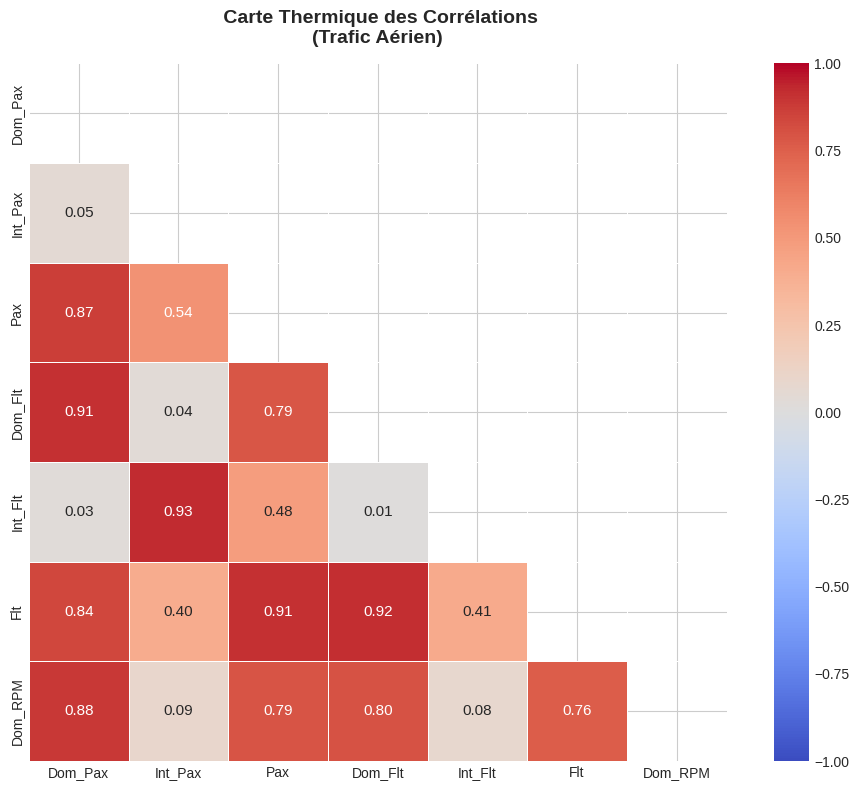


 CORRÉLATIONS FORTES (|r| > 0.7) :
---------------------------------------------
  Int_Flt ↔ Int_Pax : r = 0.927   Positive
  Dom_Flt ↔ Flt : r = 0.917   Positive
  Dom_Flt ↔ Dom_Pax : r = 0.910   Positive
  Flt ↔ Pax : r = 0.910   Positive
  Dom_Pax ↔ Dom_RPM : r = 0.885   Positive
  Dom_Pax ↔ Pax : r = 0.871   Positive
  Dom_Pax ↔ Flt : r = 0.842   Positive
  Dom_Flt ↔ Dom_RPM : r = 0.799   Positive
  Dom_RPM ↔ Pax : r = 0.790   Positive
  Dom_Flt ↔ Pax : r = 0.788   Positive
  Dom_RPM ↔ Flt : r = 0.763   Positive


In [14]:
# === 2.3 Matrice de corrélation ===
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title(' Carte Thermique des Corrélations\n(Trafic Aérien)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Corrélations fortes
print('\n CORRÉLATIONS FORTES (|r| > 0.7) :')
print('-' * 45)
strong = []
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:
            r = corr_matrix.loc[col1, col2]
            if abs(r) > 0.7:
                strong.append((col1, col2, r))

for c1, c2, r in sorted(strong, key=lambda x: abs(x[2]), reverse=True):
    direction = ' Positive' if r > 0 else ' Négative'
    print(f'  {c1} ↔ {c2} : r = {r:.3f}  {direction}')



## Section 3 : Tests d'Hypothèses


In [8]:
# === 3.1 Test 1 : Passagers nationaux vs internationaux (Test t) ===
alpha = 0.05

print('=' * 60)
print('TEST 1 : Comparaison Dom_Pax vs Int_Pax')
print('=' * 60)
print(f'H0 : μ(Dom_Pax) = μ(Int_Pax)')
print(f'H1 : μ(Dom_Pax) ≠ μ(Int_Pax)')
print(f'Méthode : Test t de Student pour échantillons indépendants')
print(f'Seuil de signification : α = {alpha}')
print()

t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f' Résultats :')
print(f'   Moyenne Dom_Pax  : {df["Dom_Pax"].mean():,.0f}')
print(f'   Moyenne Int_Pax  : {df["Int_Pax"].mean():,.0f}')
print(f'   Statistique t    : {t_stat:.4f}')
print(f'   Valeur p         : {p_value:.6f}')
print()

if p_value < alpha:
    print(f' Décision : p ({p_value:.6f}) < α ({alpha})')
    print('   → On REJETTE H0')
    print('   → Différence statistiquement significative entre les moyennes.')
else:
    print(f' Décision : p ({p_value:.6f}) ≥ α ({alpha})')
    print('   → On NE REJETTE PAS H0')
    print('   → Pas de différence significative entre les moyennes.')

TEST 1 : Comparaison Dom_Pax vs Int_Pax
H0 : μ(Dom_Pax) = μ(Int_Pax)
H1 : μ(Dom_Pax) ≠ μ(Int_Pax)
Méthode : Test t de Student pour échantillons indépendants
Seuil de signification : α = 0.05

 Résultats :
   Moyenne Dom_Pax  : 318,687
   Moyenne Int_Pax  : 159,183
   Statistique t    : 12.5085
   Valeur p         : 0.000000

 Décision : p (0.000000) < α (0.05)
   → On REJETTE H0
   → Différence statistiquement significative entre les moyennes.


TEST 2 : Corrélation entre Pax et Flt
H0 : ρ = 0  (pas de corrélation entre Pax et Flt)
H1 : ρ ≠ 0  (corrélation significative existe)
Méthode : Corrélation de Pearson
Seuil de signification : α = 0.05

 Résultats :
   Coefficient r de Pearson : 0.9097
   Valeur p                 : 0.000000

 Décision : p (0.000000) < α (0.05)
   → On REJETTE H0
   → Corrélation très forte et positive statistiquement significative (r = 0.9097).


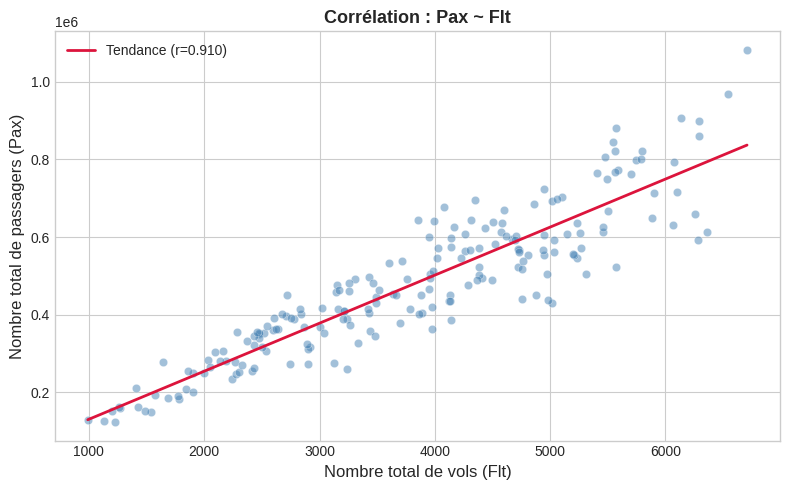

In [7]:
# === 3.2 Test 2 : Corrélation Pax ↔ Flt (Test de Pearson) ===
alpha = 0.05 # Définition de alpha pour que la cellule soit autonome

print('=' * 60)
print('TEST 2 : Corrélation entre Pax et Flt')
print('=' * 60)
print(f'H0 : ρ = 0  (pas de corrélation entre Pax et Flt)')
print(f'H1 : ρ ≠ 0  (corrélation significative existe)')
print(f'Méthode : Corrélation de Pearson')
print(f'Seuil de signification : α = {alpha}')
print()

r_pearson, p_pearson = stats.pearsonr(df['Pax'], df['Flt'])

print(' Résultats :')
print(f'   Coefficient r de Pearson : {r_pearson:.4f}')
print(f'   Valeur p                 : {p_pearson:.6f}')

# Force de la corrélation
if abs(r_pearson) >= 0.9:
    force = 'très forte'
elif abs(r_pearson) >= 0.7:
    force = 'forte'
elif abs(r_pearson) >= 0.5:
    force = 'modérée'
else:
    force = 'faible'

direction = 'positive' if r_pearson > 0 else 'négative'

print()
if p_pearson < alpha:
    print(f' Décision : p ({p_pearson:.6f}) < α ({alpha})')
    print('   → On REJETTE H0')
    print(f'   → Corrélation {force} et {direction} statistiquement significative (r = {r_pearson:.4f}).')
else:
    print(f'Décision : p ({p_pearson:.6f}) ≥ α ({alpha})')
    print('   → On NE REJETTE PAS H0')
    print('   → Pas de corrélation significative.')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Flt'], df['Pax'], alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.4)
m, b = np.polyfit(df['Flt'], df['Pax'], 1)
x_line = np.linspace(df['Flt'].min(), df['Flt'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label=f'Tendance (r={r_pearson:.3f})')
ax.set_xlabel('Nombre total de vols (Flt)', fontsize=12)
ax.set_ylabel('Nombre total de passagers (Pax)', fontsize=12)
ax.set_title('Corrélation : Pax ~ Flt', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## Section 4 : Régression Linéaire Simple


In [15]:
# === 4.1 Préparation et entraînement ===
X_simple = df[['Flt']]
y = df['Pax']

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)
y_pred_s = model_simple.predict(X_test_s)

# Métriques
r2_s   = r2_score(y_test, y_pred_s)
mse_s  = mean_squared_error(y_test, y_pred_s)
rmse_s = np.sqrt(mse_s)
mae_s  = mean_absolute_error(y_test, y_pred_s)

print('=' * 55)
print(' RÉGRESSION LINÉAIRE SIMPLE')
print('   Pax = f(Flt)')
print('=' * 55)
print(f'Équation : Pax = {model_simple.intercept_:,.2f} + {model_simple.coef_[0]:,.2f} × Flt')
print()
print(' Métriques de performance (ensemble de test) :')
print(f'   R²   : {r2_s:.4f}')
print(f'   MSE  : {mse_s:,.2f}')
print(f'   RMSE : {rmse_s:,.2f}')
print(f'   MAE  : {mae_s:,.2f}')

 RÉGRESSION LINÉAIRE SIMPLE
   Pax = f(Flt)
Équation : Pax = 5,931.68 + 124.04 × Flt

 Métriques de performance (ensemble de test) :
   R²   : 0.7929
   MSE  : 6,739,874,478.01
   RMSE : 82,096.74
   MAE  : 67,848.78


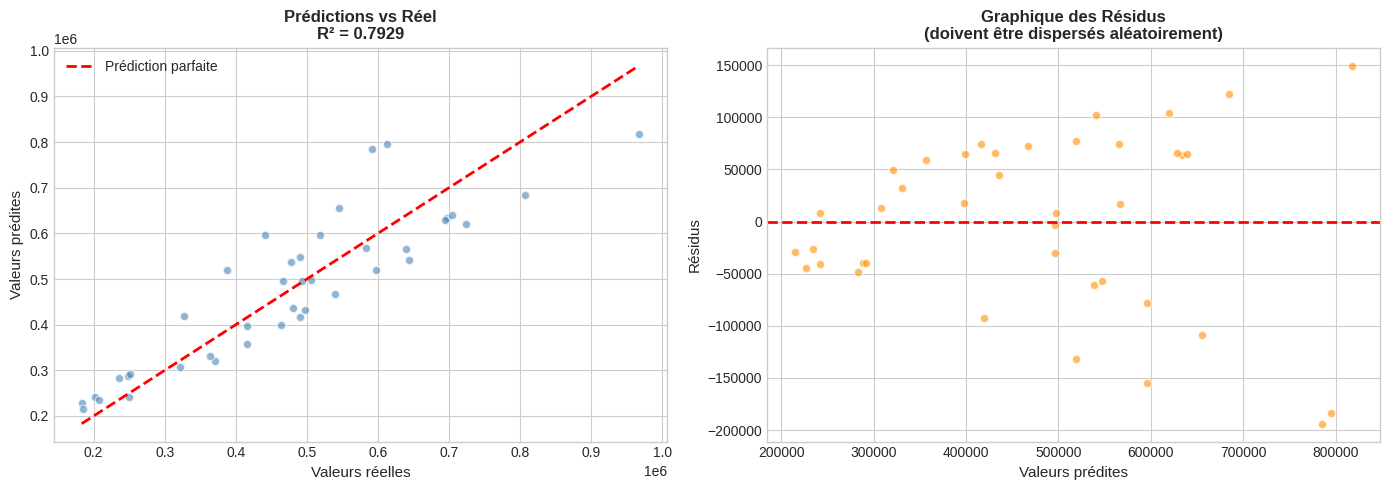

 Interprétation des résidus :
   • Si dispersés aléatoirement autour de 0 → Hypothèses de régression respectées
   • Si motif visible → Relation non-linéaire possible ou variable manquante


In [16]:
# === 4.2 Visualisations ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Prédictions vs Valeurs réelles
axes[0].scatter(y_test, y_pred_s, alpha=0.6, color='steelblue', edgecolors='white')
lim = [min(y_test.min(), y_pred_s.min()), max(y_test.max(), y_pred_s.max())]
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles', fontsize=11)
axes[0].set_ylabel('Valeurs prédites', fontsize=11)
axes[0].set_title(f'Prédictions vs Réel\nR² = {r2_s:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()

# Graphique 2 : Résidus
residuals = y_test - y_pred_s
axes[1].scatter(y_pred_s, residuals, alpha=0.6, color='darkorange', edgecolors='white')
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Valeurs prédites', fontsize=11)
axes[1].set_ylabel('Résidus', fontsize=11)
axes[1].set_title('Graphique des Résidus\n(doivent être dispersés aléatoirement)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(' Interprétation des résidus :')
print('   • Si dispersés aléatoirement autour de 0 → Hypothèses de régression respectées')
print('   • Si motif visible → Relation non-linéaire possible ou variable manquante')

---
## Section 5 : Régression Linéaire Multiple


In [19]:
# === 5.1 Sélection des caractéristiques et mise à l'échelle ===
features = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
X_multi = df[features]

X_train_m, X_test_m, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Mise à l'échelle (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)   # Ajuster UNIQUEMENT sur train
X_test_scaled  = scaler.transform(X_test_m)         # Transformer test

# Entraînement
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)
y_pred_m = model_multi.predict(X_test_scaled)

# Métriques
r2_m   = r2_score(y_test, y_pred_m)
mse_m  = mean_squared_error(y_test, y_pred_m)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test, y_pred_m)

print('=' * 55)
print(' RÉGRESSION LINÉAIRE MULTIPLE')
print(f'   Prédicteurs : {features}')
print('=' * 55)
print(f'Ordonnée à l\'origine : {model_multi.intercept_:,.2f}')
print()
print('Coefficients (échelle standardisée) :')
for feat, coef in zip(features, model_multi.coef_):
    print(f'   {feat:12s} : {coef:>12,.2f}')
print()
print(' Métriques de performance (ensemble de test) :')
print(f'   R²   : {r2_m:.4f}')
print(f'   MSE  : {mse_m:,.2f}')
print(f'   RMSE : {rmse_m:,.2f}')
print(f'   MAE  : {mae_m:,.2f}')

 RÉGRESSION LINÉAIRE MULTIPLE
   Prédicteurs : ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Ordonnée à l'origine : 478,385.57

Coefficients (échelle standardisée) :
   Dom_Pax      :   156,436.30
   Int_Pax      :    88,072.97
   Dom_Flt      :        -0.08
   Int_Flt      :         0.01
   Dom_RPM      :         0.04

 Métriques de performance (ensemble de test) :
   R²   : 1.0000
   MSE  : 0.33
   RMSE : 0.57
   MAE  : 0.54


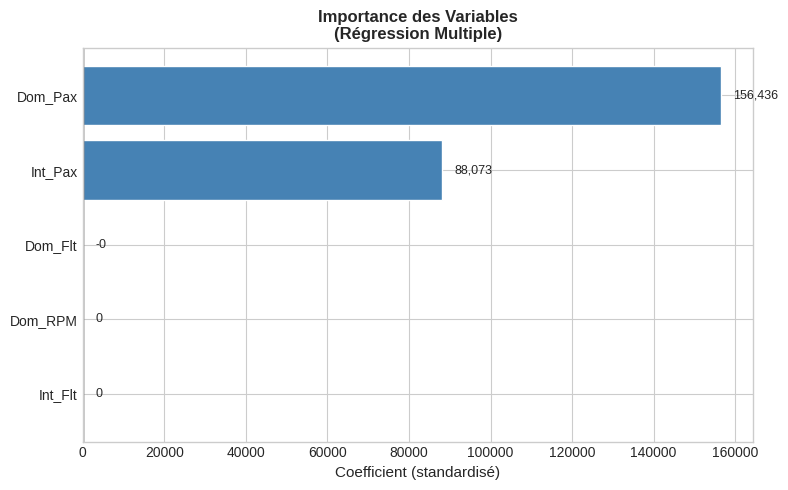

In [20]:
# === 5.2 Importance des variables (coefficients) ===
coef_df = pd.DataFrame({'Variable': features, 'Coefficient': model_multi.coef_})
coef_df['|Coefficient|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coefficient|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (standardisé)', fontsize=11)
ax.set_title('Importance des Variables\n(Régression Multiple)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (max(coef_df['Coefficient']) * 0.02), bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 6 : Comparaison et Analyse des Modèles


In [21]:
# === 6.1 Tableau comparatif ===
comparison = pd.DataFrame({
    'Modèle': ['Régression Simple', 'Régression Multiple'],
    'R²':   [r2_s,   r2_m],
    'RMSE': [rmse_s, rmse_m],
    'MAE':  [mae_s,  mae_m]
})

print('=' * 60)
print(' COMPARAISON DES MODÈLES')
print('=' * 60)
display(comparison.set_index('Modèle').round(4))

# Calcul des améliorations
r2_improvement   = ((r2_m   - r2_s)   / r2_s)   * 100
rmse_improvement = ((rmse_s - rmse_m)  / rmse_s) * 100
mae_improvement  = ((mae_s  - mae_m)   / mae_s)  * 100

print('\n AMÉLIORATIONS (Simple → Multiple) :')
print(f'   R²   : {r2_improvement:+.2f}%')
print(f'   RMSE : {rmse_improvement:+.2f}%  (réduction = meilleur)')
print(f'   MAE  : {mae_improvement:+.2f}%  (réduction = meilleur)')

winner = 'Multiple' if r2_m > r2_s else 'Simple'
print(f'\n Modèle le plus performant : Régression {winner}')

 COMPARAISON DES MODÈLES


,R²,RMSE,MAE
Modèle,,,
Régression Simple,0.7929,82096.7385,67848.7827
Régression Multiple,1.0000,0.5732,0.5397



 AMÉLIORATIONS (Simple → Multiple) :
   R²   : +26.12%
   RMSE : +100.00%  (réduction = meilleur)
   MAE  : +100.00%  (réduction = meilleur)

 Modèle le plus performant : Régression Multiple


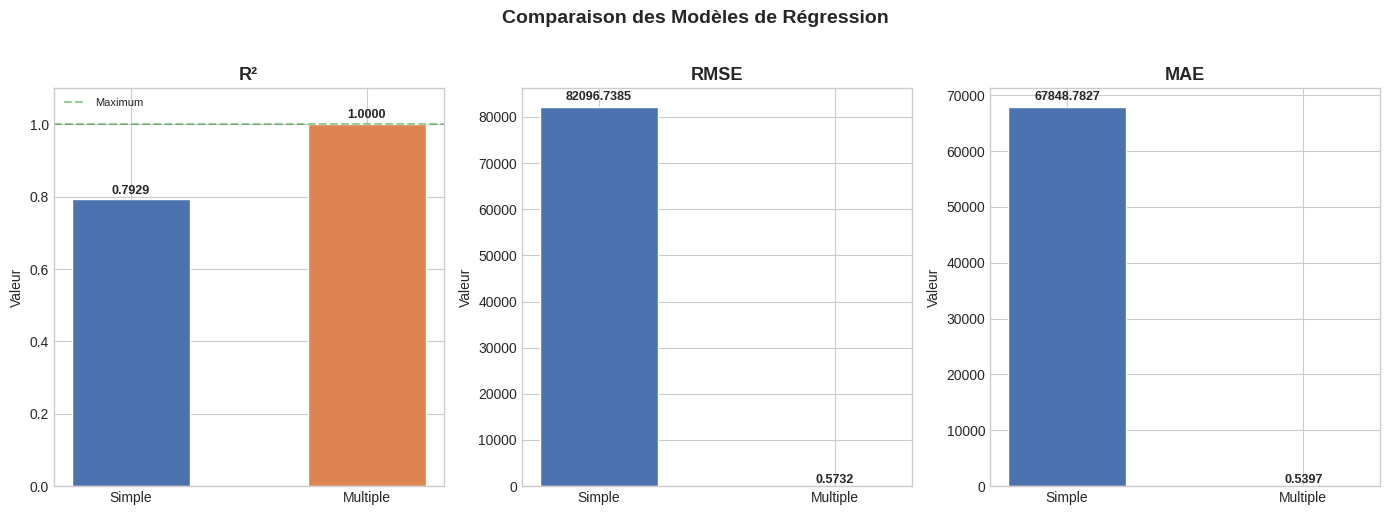

In [22]:
# === 6.2 Visualisation comparative ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['R²', 'RMSE', 'MAE']
values_s = [r2_s, rmse_s, mae_s]
values_m = [r2_m, rmse_m, mae_m]
colors_s = ['#4C72B0', '#4C72B0', '#4C72B0']
colors_m = ['#DD8452', '#DD8452', '#DD8452']

for i, (ax, metric, vs, vm) in enumerate(zip(axes, metrics, values_s, values_m)):
    bars = ax.bar(['Simple', 'Multiple'], [vs, vm],
                  color=[colors_s[i], colors_m[i]], edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valeur', fontsize=10)
    for bar, val in zip(bars, [vs, vm]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if metric == 'R²':
        ax.set_ylim(0, 1.1)
        ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.4, label='Maximum')
        ax.legend(fontsize=8)

fig.suptitle('Comparaison des Modèles de Régression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 Section 7 : Analyses Statistiques et Conclusions


In [25]:
# === 7. Résumé final et recommandations ===
print('=' * 65)
print('  SYNTHÈSE DES RÉSULTATS')
print('=' * 65)

print('''
🔬 1. TESTS D'HYPOTHÈSES
   Test t (Dom_Pax vs Int_Pax) :''')
if p_value < 0.05:
    print('    Différence significative → Les vols intérieurs et internationaux')
    print('      attirent des volumes de passagers statistiquement différents.')
else:
    print('   Pas de différence significative entre Dom_Pax et Int_Pax.')

print(f'''
   Corrélation Pearson (Pax ~ Flt) :''')
if p_pearson < 0.05:
    print(f'    Corrélation significative (r = {r_pearson:.4f})')
    print(f'      → Le nombre de vols est un prédicteur fort du trafic passagers.')

print(f'''
 2. PERFORMANCE DES MODÈLES DE RÉGRESSION
   Régression Simple  (Pax ~ Flt)         : R² = {r2_s:.4f}
   Régression Multiple (Pax ~ 5 variables) : R² = {r2_m:.4f}

   La régression multiple explique {r2_m*100:.1f}% de la variance du
   nombre de passagers, contre {r2_s*100:.1f}% pour le modèle simple.

 3. PRINCIPAUX RÉSULTATS DE CORRÉLATION
   • Les vols intérieurs (Dom_Flt) et internationaux (Int_Flt) sont
     fortement corrélés à leurs passagers respectifs.
   • La variable Dom_RPM (km-passagers payants) reflète l'activité
     économique du trafic intérieur.

4. RECOMMANDATIONS OPÉRATIONNELLES
   a) Planification des capacités : Utiliser le modèle multiple pour
      anticiper la demande passagers en fonction des rotations prévues.
   b) Optimisation des ressources : Les vols intérieurs et internationaux
      étant indépendants, les gérer avec des stratégies distinctes.
   c) Suivi des KPI : Surveiller Dom_RPM comme indicateur avancé de
      rentabilité pour les routes domestiques.
   d) Amélioration du modèle : Intégrer des variables saisonnières
      (mois, jours fériés) pour gagner en précision.
''')

print('=' * 65)
print('=' * 65)

  SYNTHÈSE DES RÉSULTATS

🔬 1. TESTS D'HYPOTHÈSES
   Test t (Dom_Pax vs Int_Pax) :
    Différence significative → Les vols intérieurs et internationaux
      attirent des volumes de passagers statistiquement différents.

   Corrélation Pearson (Pax ~ Flt) :
    Corrélation significative (r = 0.9097)
      → Le nombre de vols est un prédicteur fort du trafic passagers.

 2. PERFORMANCE DES MODÈLES DE RÉGRESSION
   Régression Simple  (Pax ~ Flt)         : R² = 0.7929
   Régression Multiple (Pax ~ 5 variables) : R² = 1.0000
   
   La régression multiple explique 100.0% de la variance du
   nombre de passagers, contre 79.3% pour le modèle simple.

 3. PRINCIPAUX RÉSULTATS DE CORRÉLATION
   • Les vols intérieurs (Dom_Flt) et internationaux (Int_Flt) sont
     fortement corrélés à leurs passagers respectifs.
   • La variable Dom_RPM (km-passagers payants) reflète l'activité
     économique du trafic intérieur.

4. RECOMMANDATIONS OPÉRATIONNELLES
   a) Planification des capacités : Utiliser l